# Mapping the Parameter Space of $n_s$ and $r$

This notebook uses the `numerical_observables_calculation` pipeline to explore how initial field configurations $(\phi_i, y_i)$ affect the observed primordial power spectrum. 

We will:
1. Define a grid of initial conditions.
2. Run the exact numerical solver for each point.
3. Visualize the results using heatmaps (how $n_s$ varies) and trajectory plots in the $n_s$ vs $r$ plane.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
import os
from tqdm.notebook import tqdm

# Import our new pipeline and model
sys.path.append(os.path.abspath('..'))
from inflation_models import HiggsModel
import numerical_observables_calculation as calc

# Setup Plotting
plt.style.use('seaborn-v0_8-paper')
sns.set_context("talk")
params = {'legend.fontsize': 'medium',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'medium',
         'ytick.labelsize':'medium'}
plt.rcParams.update(params)
sns.set_palette("viridis")

## 1. Grid Definition
We explore a range of initial values around the standard USR (Ultra Slow Roll) transition points for Higgs Inflation.

In [ ]:
model = HiggsModel(xi=1000, lam=0.13)

# Define Grid
phi0_vals = np.linspace(5.4, 5.6, 10) 
yi_vals = np.linspace(-0.2, -0.1, 10)

all_results = []

print(f"Starting grid search on {len(phi0_vals) * len(yi_vals)} configurations...")

for p in tqdm(phi0_vals, desc="Phi0 Index"):
    for v in yi_vals:
        custom_T_span = np.linspace(0, 5000, 10000)
        res = calc.run_inflation_protocol(model, phi0=p, yi=v, delta=1e-5, T_span_bg=custom_T_span)

        
        if res["status"] == "success":
            all_results.append({
                'phi0': p,
                'yi': v,
                'ns': res['ns'],
                'r': res['r'],
                'ns_SR': res['ns_SR'],
                'r_SR': res['r_SR'],
                'N_total': res['N_total'],
                'Ps': res['P_S']
            })


df = pd.DataFrame(all_results)
print("Grid search complete!")

Starting grid search on 100 configurations...


Phi0 Index:   0%|          | 0/10 [00:00<?, ?it/s]

## 2. Visualizing how $n_s$ moves in the Initial Condition Plane

We use heatmaps to see where the field configuration leads to higher or lower spectral indices.

<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
C:\Users\diego\AppData\Local\Temp\ipykernel_7404\1984381722.py:14: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("Initial Field $\phi_0$")


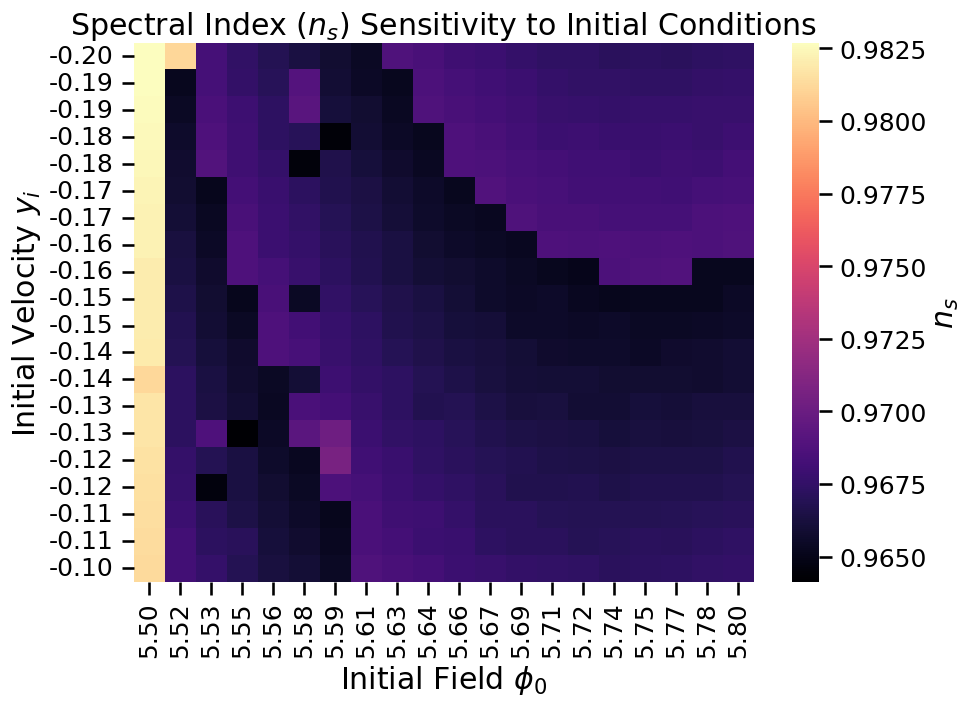

In [11]:
pivot_df = df.pivot(index="yi", columns="phi0", values="ns")

plt.figure(figsize=(10, 7))
#ax = sns.heatmap(pivot_df, annot=True, fmt=".3f", cmap="magma",
#                 cbar_kws={'label': '$n_s$'})
ax = sns.heatmap(pivot_df, cmap="magma",
                 cbar_kws={'label': '$n_s$'})

# format tick labels
ax.set_xticklabels([f"{x:.2f}" for x in pivot_df.columns])
ax.set_yticklabels([f"{y:.2f}" for y in pivot_df.index])

plt.title("Spectral Index ($n_s$) Sensitivity to Initial Conditions")
plt.xlabel("Initial Field $\phi_0$")
plt.ylabel("Initial Velocity $y_i$")
plt.show()

--- Statistical Analysis of n_s: Exact MS vs Slow-Roll ---
Mean Absolute Error (MAE): 1.510e-03
Root Mean Square Error (RMSE): 3.158e-03
Max Absolute Error:        1.342e-02
Average Variance (%):      0.15602%
--------------------------------------------------------


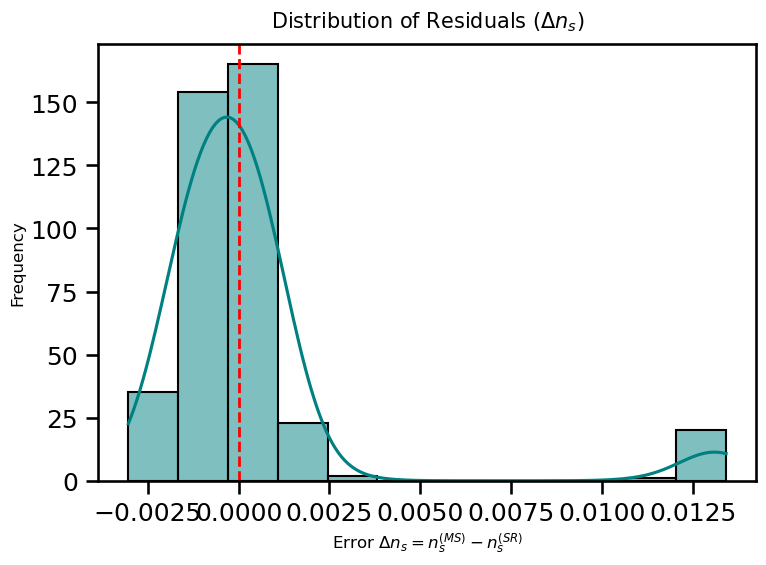

In [29]:
# 1. Calculate the Error / Residuals
df['delta_ns'] = df['ns'] - df['ns_SR']
df['abs_error_ns'] = df['delta_ns'].abs()
df['pct_error_ns'] = (df['abs_error_ns'] / df['ns_SR']) * 100

# 2. Print Key Statistical Metrics
mae = df['abs_error_ns'].mean()
max_err = df['abs_error_ns'].max()
rmse = np.sqrt((df['delta_ns']**2).mean())

print(f"--- Statistical Analysis of n_s: Exact MS vs Slow-Roll ---")
print(f"Mean Absolute Error (MAE): {mae:.3e}")
print(f"Root Mean Square Error (RMSE): {rmse:.3e}")
print(f"Max Absolute Error:        {max_err:.3e}")
print(f"Average Variance (%):      {df['pct_error_ns'].mean():.5f}%")
print("-" * 56)

# =========================================================
# GRAPH 1: Distribution of Residuals (Delta ns)
# =========================================================
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='delta_ns', kde=True, color='teal', bins=12, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title("Distribution of Residuals ($\\Delta n_s$)", fontsize=15, pad=12)
plt.xlabel("Error $\\Delta n_s = n_s^{(MS)} - n_s^{(SR)}$", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()




<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
C:\Users\diego\AppData\Local\Temp\ipykernel_7404\1446146561.py:26: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("Initial Field $\phi_0$", fontsize=13)


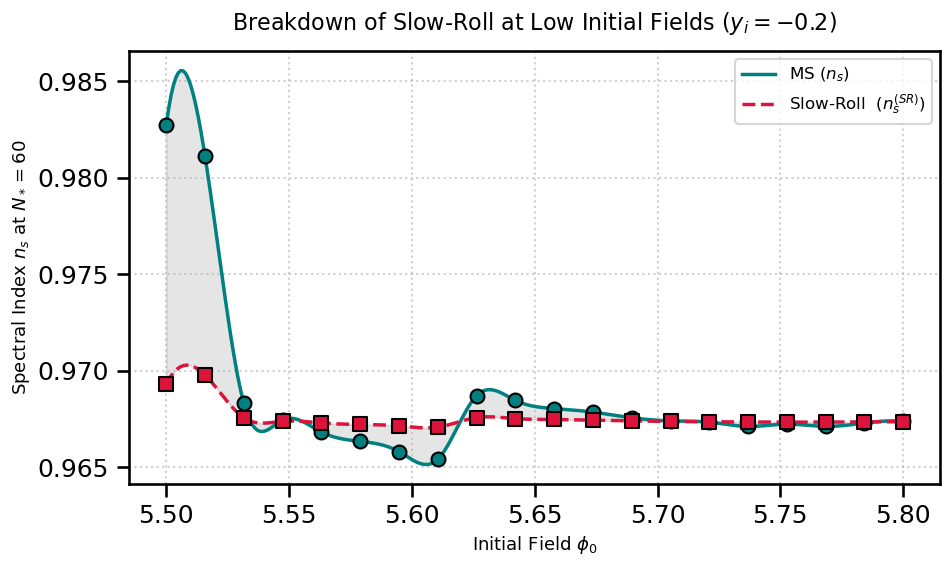

In [27]:
plt.figure(figsize=(10, 6))

df_slice = df[df['yi'] == -0.2].sort_values('phi0')

x_raw = df_slice['phi0']
y_ms_raw = df_slice['ns']
y_sr_raw = df_slice['ns_SR']

x_smooth = np.linspace(x_raw.min(), x_raw.max(), 300)

spline_ms = make_interp_spline(x_raw, y_ms_raw, k=3)
spline_sr = make_interp_spline(x_raw, y_sr_raw, k=3)

y_ms_smooth = spline_ms(x_smooth)
y_sr_smooth = spline_sr(x_smooth)

plt.plot(x_smooth, y_ms_smooth, linestyle='-', linewidth=2.5, color='teal', label='MS ($n_s$)')
plt.plot(x_smooth, y_sr_smooth, linestyle='--', linewidth=2.5, color='crimson', label='Slow-Roll  ($n_s^{(SR)}$)')

plt.scatter(x_raw, y_ms_raw, color='teal', s=100, marker='o', zorder=5, edgecolor='black')
plt.scatter(x_raw, y_sr_raw, color='crimson', s=100, marker='s', zorder=5, edgecolor='black')

plt.fill_between(x_smooth, y_ms_smooth, y_sr_smooth, color='gray', alpha=0.2, label='')

plt.title("Breakdown of Slow-Roll at Low Initial Fields ($y_i = -0.2$)", fontsize=16, pad=15)
plt.xlabel("Initial Field $\phi_0$", fontsize=13)
plt.ylabel("Spectral Index $n_s$ at $N_*=60$", fontsize=13)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()


## 4. e-folds Correlation

How does the total duration of inflation relate to our observables? Configurations that lead to very long inflation (perhaps entering a USR phase) often shift $n_s$ significantly.

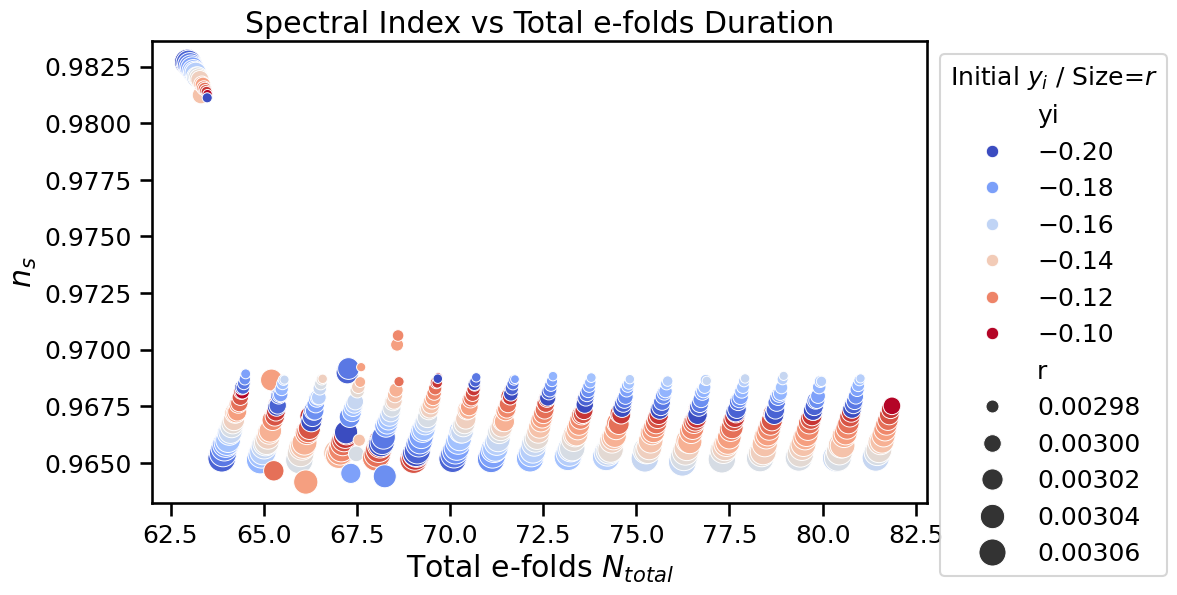

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='N_total', y='ns', hue='yi', size='r', sizes=(40, 400), palette='coolwarm')
plt.title("Spectral Index vs Total e-folds Duration")
plt.xlabel("Total e-folds $N_{total}$")
plt.ylabel("$n_s$")
plt.legend(title="Initial $y_i$ / Size=$r$", loc='upper left', bbox_to_anchor=(1, 1))
plt.show()